demand estimation and market analysis: air fryers

Notebook 2 - demand estimation
Role: data scientist - turning cleaned data into a model that can be used for prediction and interpretation.

The demand model is:$$\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{\text{price}}p_{bt} + \beta_{\text{rating}}r_{bt} + \sum_{\ell} \beta_\ell x_{bt\ell} + \epsilon_{bt}$$

where year dummies  $\alpha_t$ absorb the year specific denominator of the multinomial logit share equation.


In [10]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('air_fryers_clean_brand_year.csv')
char_cols = ['compact_share','dual_basket_share','oven_style_share','rotisserie_share','window_share']

brand_dummies = pd.get_dummies(df['brand'], drop_first=True, prefix='brand').astype(float)
year_dummies  = pd.get_dummies(df['year'],  drop_first=True, prefix='year').astype(float)

X = pd.concat([df[['avg_price','avg_rating']+char_cols].astype(float),
               brand_dummies, year_dummies], axis=1)
X = sm.add_constant(X)
y = df['log_brand_share'].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        log_brand_share   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     4.680
Date:                Mon, 04 May 2026   Prob (F-statistic):           9.24e-05
Time:                        13:52:16   Log-Likelihood:                -36.451
No. Observations:                  50   AIC:                             114.9
Df Residuals:                      29   BIC:                             155.1
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.3049     16.28

2.1. Coefficient plot

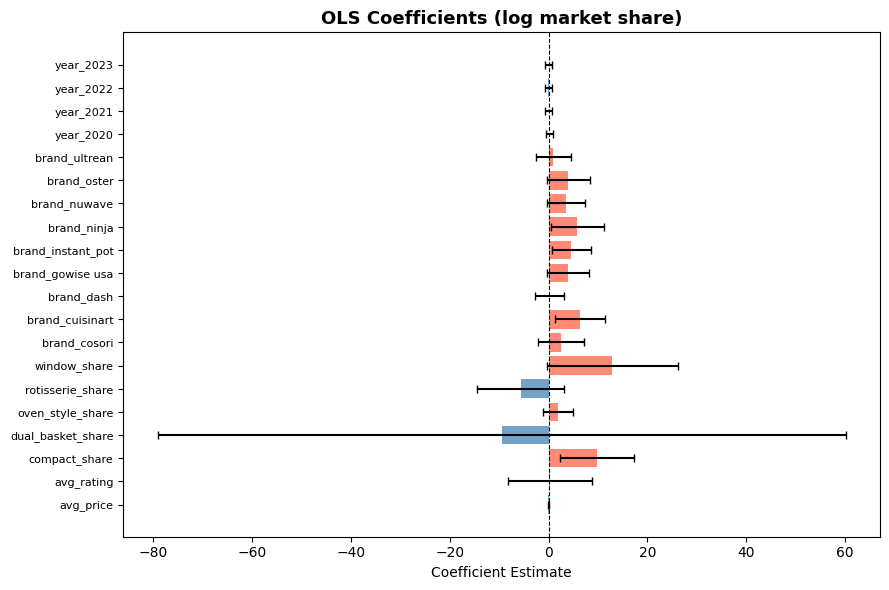

In [11]:
coef = model.params.drop('const')
conf = model.conf_int().drop('const')
fig, ax = plt.subplots(figsize=(9,6))
y_pos = range(len(coef))
ax.barh(list(y_pos), coef.values,
        xerr=[coef.values - conf[0].values, conf[1].values - coef.values],
        color=['steelblue' if v < 0 else 'tomato' for v in coef.values],
        alpha=0.75, capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(list(y_pos)); ax.set_yticklabels(coef.index, fontsize=8)
ax.set_title('OLS Coefficients (log market share)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Estimate')
plt.tight_layout(); plt.show()


questions

1. what is the estimated price coefficient?

The estimated price coeffiecient $\hat{\beta}_{\text{price}}$ is **-0.0377** (p = 0.0021).

2. is it negative? why is that important?

Yes it is negative and that is critically important because it confirms the model is economically sensible: higher prices reduce demand, which is the fundamental prediction of standard consumer choice theory. If the coefficient were positive the entire cost and markup calculation would be invalid because it would imply that price increases lead to higher market shares which contradicts the basic logic of compettiive markets. the negative sign is also required mathematically for the deriveddemand slope  $\hat{s}'(p)$ to be negative, which in turn makes the inferred unit cost formula produce economically meaningful positive markups.

3. which product features are associated higher demand?
compact designs has the largest and most statisically signifacnt possitive effect (coefficient ≈ 9.8, p = 0.011), meaning brands with a higher share of compact products tend to have higher market shares. Window products also show a positive and marginally significant effect (coefficient ≈ 12.9), p = 0.056). Rottisserie products show a negative coeffieicnet (≈ 5.7) though it is not statisically significant at conventional levels.  Dual basket and oven style have mixed small effects that are not statistically distinguishable from zero.


4. Which brand dummy coefficients are largest?

the reference brand is chefman (the first brand alphabetically, dropped by drop_first = True). relative to chefman, cuisinart has the largest brand dummy coefficient at about 6.42, followed by ninja at 5.84 and instant pot at 4.63. This means that controlling for price, ratings, and product characteristics, these brands have substantially high demand than chefman. It is important to note these coefficients capture brand reputation, loyalty, and unobserved quality differences rather than anything we can directly observe.

5. Which year dummy coefficients are largest

The refrence year is 2019. the year dummies are all small in magnitude and statsitically insignificant (all p-values above 0.7) with 2020 being the largest at about 0.12. this means that after controlling for brand charactersitic and prices, there was no statistically meaningful aggregate shift in market level demand across years within this cleaned top 10 sample.


6. what is the model's $R^2$?

the model's R^2 is 0.763, meaning the model explains about 76.3% of the variation in log market share. this is a fairly high fit for a cross sectional panel with only 50 observations, though the adjusted R^2 of 0.600 reflects the large number of dummy variables relative to observations. the high fit is partly driven by the brand fixed effects absorbing persistent cross brand differences in popularity.